In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, losses

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F


## MNIST 모델 학습

In [18]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST 공식 평균/표준편차
])

In [19]:
mnist_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

mnist_train_loader = DataLoader(mnist_train_dataset, batch_size=64, shuffle=True)
mnist_test_loader = DataLoader(mnist_test_dataset, batch_size=1000, shuffle=False)

In [20]:
class MNIST_CNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   
        )
        # 합성곱 블록 2: 32채널 → 64채널
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   
        )
        # 완전연결층
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


In [21]:
mnist_criterion = nn.CrossEntropyLoss()
mnist_optimizer = optim.Adam(mnist_model.parameters(), lr=0.001)

In [22]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), correct / len(loader.dataset) * 100

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            
    return total_loss / len(loader), correct / len(loader.dataset) * 100

In [23]:
EPOCHS = 10 # 테스트를 위해 10으로 조정 (필요시 20으로 변경하세요)
best_acc = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(mnist_model, mnist_train_loader, mnist_criterion, mnist_optimizer, device)
    test_loss, test_acc = evaluate(mnist_model, mnist_test_loader, mnist_criterion, device)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(mnist_model.state_dict(), 'best_mnist_model.pth')
        print("💡 최고 정확도 갱신! 모델 저장됨.")

print(f"\n최고 테스트 정확도: {best_acc:.2f}%")

Epoch  1/10 | Train Loss: 0.0231 Acc: 99.3% | Test Loss: 0.0309 Acc: 99.2%
💡 최고 정확도 갱신! 모델 저장됨.
Epoch  2/10 | Train Loss: 0.0192 Acc: 99.4% | Test Loss: 0.0295 Acc: 99.3%
💡 최고 정확도 갱신! 모델 저장됨.
Epoch  3/10 | Train Loss: 0.0192 Acc: 99.4% | Test Loss: 0.0275 Acc: 99.2%
Epoch  4/10 | Train Loss: 0.0164 Acc: 99.5% | Test Loss: 0.0274 Acc: 99.4%
💡 최고 정확도 갱신! 모델 저장됨.
Epoch  5/10 | Train Loss: 0.0148 Acc: 99.5% | Test Loss: 0.0325 Acc: 99.3%
Epoch  6/10 | Train Loss: 0.0146 Acc: 99.5% | Test Loss: 0.0307 Acc: 99.3%
Epoch  7/10 | Train Loss: 0.0140 Acc: 99.5% | Test Loss: 0.0330 Acc: 99.3%
Epoch  8/10 | Train Loss: 0.0121 Acc: 99.6% | Test Loss: 0.0335 Acc: 99.3%
Epoch  9/10 | Train Loss: 0.0108 Acc: 99.7% | Test Loss: 0.0379 Acc: 99.2%
Epoch 10/10 | Train Loss: 0.0124 Acc: 99.6% | Test Loss: 0.0295 Acc: 99.3%

최고 테스트 정확도: 99.35%


In [24]:
def visualize_results(model, loader, device, num_images=10):
    model.eval() # 평가 모드
    images, labels = next(iter(loader)) # 테스트 데이터 한 배치를 가져옴
    images, labels = images.to(device), labels.to(device)
    
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    
    
    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    predicted = predicted.cpu().numpy()

    plt.figure(figsize=(15, 6))
    for i in range(num_images):
        plt.subplot(2, 5, i + 1)
        img = images[i].squeeze() # (1, 28, 28) -> (28, 28)
        plt.imshow(img, cmap='gray')
        
        color = 'blue' if predicted[i] == labels[i] else 'red'
        
        plt.title(f"True: {labels[i]}\nPred: {predicted[i]}", color=color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

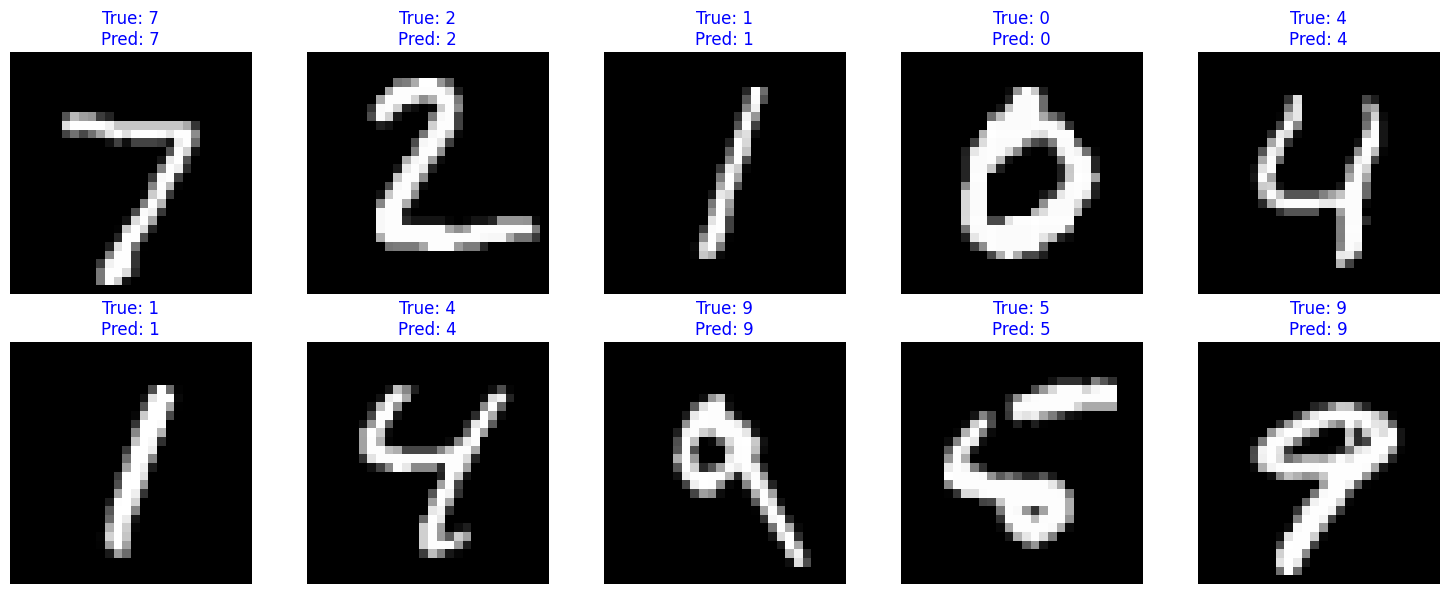

In [25]:
visualize_results(mnist_model, mnist_test_loader, device)

## CIFAR10 데이터 학습

In [26]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # 좌우 반전 (데이터 증강)
    transforms.RandomCrop(32, padding=4),        # 랜덤 크롭
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # RGB 평균
                         (0.2023, 0.1994, 0.2010))   # RGB 표준편차
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

cifar10_train_dataset = datasets.CIFAR10('./data', train=True,  download=True, transform=train_transform)
cifar10_test_dataset  = datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)

Files already downloaded and verified


c:\Users\wjkim\miniconda3\envs\uos_Reliable_AI\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [27]:
# 데이터 타입 변환 및 정규화 (0~255 -> 0~1)
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']
cifar10_train_loader = DataLoader(cifar10_train_dataset, batch_size=128, shuffle=True,  num_workers=2)
cifar10_test_loader  = DataLoader(cifar10_test_dataset,  batch_size=128, shuffle=False, num_workers=2)

In [28]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32×32 → 16×16
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16×16 → 8×8
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 8×8 → 4×4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU 사용 가능:", torch.cuda.get_device_name(0))
cifar10_model = CIFAR_CNN().to(device)

total_params = sum(p.numel() for p in cifar10_model.parameters())
print(f"파라미터 수: {total_params:,}")


GPU 사용 가능: NVIDIA GeForce RTX 4080
파라미터 수: 1,147,914


In [29]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    if device.type == 'cuda':
        print("학습에 사용할 GPU:", torch.cuda.get_device_name(0))
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cifar10_model.parameters(), lr=0.001)

EPOCHS = 20
best_acc = 0


In [30]:
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(cifar10_model, cifar10_train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(cifar10_model, cifar10_test_loader, criterion, device)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(cifar10_model.state_dict(), 'best_cifar_model.pth')
    

print(f"\n최고 테스트 정확도: {best_acc:.2f}%")

학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  1/20 | Train Loss: 1.5684 Acc: 42.1% | Test Loss: 1.2131 Acc: 55.8%
학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  2/20 | Train Loss: 1.2435 Acc: 54.9% | Test Loss: 1.0307 Acc: 62.9%
학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  3/20 | Train Loss: 1.1166 Acc: 60.1% | Test Loss: 0.9111 Acc: 67.9%
학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  4/20 | Train Loss: 1.0160 Acc: 63.9% | Test Loss: 0.9153 Acc: 68.2%
학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  5/20 | Train Loss: 0.9482 Acc: 66.4% | Test Loss: 0.8145 Acc: 71.7%
학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  6/20 | Train Loss: 0.9056 Acc: 68.4% | Test Loss: 0.7440 Acc: 73.5%
학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  7/20 | Train Loss: 0.8650 Acc: 69.8% | Test Loss: 0.7282 Acc: 74.6%
학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  8/20 | Train Loss: 0.8315 Acc: 71.0% | Test Loss: 0.7044 Acc: 75.2%
학습에 사용할 GPU: NVIDIA GeForce RTX 4080
Epoch  9/20 | Train Loss: 0.8063 Acc: 72.2% | Test Loss: 0.7247 Acc

## Problem 1 Targeted FGSM

In [31]:
def fgsm_targeted(model, x, target, eps):
    # 입력 이미지 x의 기울기를 추적하도록 설정 
    x.requires_grad_(True)
    
    # 1. 입력 x에 대한 모델의 출력(logits) 
    logits = model(x)
    
    # 2. 출력값과 타겟 라벨(오답) 사이의 Loss 계산
    loss = F.cross_entropy(logits, target)
    
    # 3. 역전파를 통해 입력 x에 대한 기울기 계산
    mnist_model.zero_grad()
    cifar10_model.zero_grad()
    loss.backward()
    
    # 4. 적대적 이미지 생성 (Targeted이므로 마이너스 부호) 
    
    x_adv = x - eps * x.grad.sign()
    
    # 5. 이미지 범위를 [0, 1]로 제한 
    x_adv = torch.clamp(x_adv, 0, 1)
    
    return x_adv

### Problem 1-1 MNIST

In [32]:
def mnist_wrapped_model(x):
    # 입력을 [0, 1]에서 [-0.4242, 2.8215]로 변환 후 모델 통과
    mean = 0.1307
    std = 0.3081
    x_norm = (x - mean) / std
    return mnist_model(x_norm)

In [33]:
import os
os.makedirs('results', exist_ok=True)

In [34]:
def visualize_attack(x, x_adv, target_label, clean_pred, adv_pred, index, eps):
    org_img = x.squeeze().cpu().detach().numpy()
    adv_img = x_adv.squeeze().cpu().detach().numpy()
    
    # 1. 노이즈(Perturbation) 계산: x_adv - x 
    # 차이를 잘 보이게 하기 위해 절대값을 취함
    perturbation = adv_img - org_img
    
    # 시각화 설정 (3개 이미지를 나란히 배치) [cite: 121]
    plt.figure(figsize=(12, 4))
    
    # (1) 원본 이미지 [cite: 122]
    plt.subplot(1, 3, 1)
    plt.imshow(org_img, cmap='gray')
    plt.title(f"Original\nPred: {clean_pred}")
    plt.axis('off')
    
    # (2) 노이즈 (차이점) 
    plt.subplot(1, 3, 2)
    # 노이즈가 아주 미세하므로 가시성을 위해 값을 키울 수 있음
    plt.imshow(perturbation, cmap='gray') 
    plt.title("Perturbation\n(Magnified)")
    plt.axis('off')
    
    # (3) 적대적 이미지 [cite: 123]
    plt.subplot(1, 3, 3)
    plt.imshow(adv_img, cmap='gray')
    plt.title(f"Adversarial\nTarget: {target_label}, Pred: {adv_pred}")
    plt.axis('off')
    
    # 이미지 파일 저장 [cite: 125]
    plt.tight_layout()
    plt.savefig(f'targetedFGSM_results/attack_sample_eps{eps}_{index}.png')
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\Dev\\UOS\\targetedFGSM_results\\attack_sample_eps3_0.png'

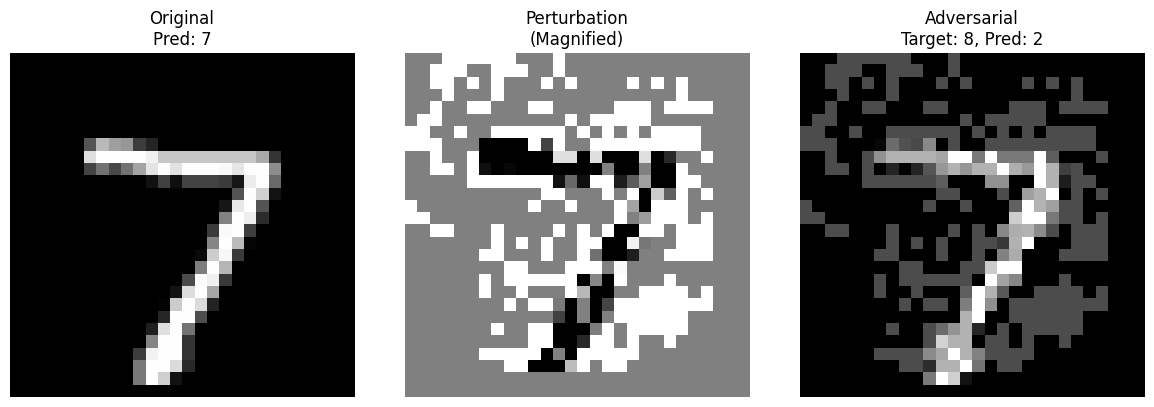

In [35]:
mnist_model.eval()
targeted_success = 0
total_samples = 0
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081
saved_count = 0

for data, label in mnist_test_loader:
    data, label = data.to(device), label.to(device)
    
    # 현재 정규화된 데이터를 [0, 1] 범위로 복구
    data_raw = data * MNIST_STD + MNIST_MEAN
    
    # 모델의 초기 예측값 확인 (정답을 맞힌 데이터만 사용) [cite: 27]
    with torch.no_grad():
        output = mnist_wrapped_model(data_raw)
        init_pred = output.max(1)[1]
    
    mask = (init_pred == label)
    if not mask.any(): continue

    # [0, 1] 범위의 깨끗한 이미지 x 준비
    x = data_raw[mask].clone().detach()
    y_true = label[mask]
    target_label = (y_true + 1) % 10 # 타겟 클래스 설정 [cite: 32]

    # 공격 수행 (wrapped_model을 사용하여 정규화 문제 해결)
    x_adv = fgsm_targeted(mnist_wrapped_model, x, target_label, eps=0.3)
    
    # 최종 결과 확인
    with torch.no_grad():
        output_adv = mnist_wrapped_model(x_adv)
        final_pred = output_adv.max(1)[1]

    for i in range(len(x)):                                        
        if saved_count < 5:                                        
            visualize_attack(
                x[i:i+1], x_adv[i:i+1],
                target_label[i].item(),
                y_true[i].item(),
                final_pred[i].item(),
                saved_count, 3
            )
            saved_count += 1
        else:
            break
    
    targeted_success += (final_pred == target_label).sum().item()
    total_samples += x.size(0)
    
    if total_samples >= 100: # 최소 100개 샘플 조건 충족 [cite: 116]
        break

print(f"Targeted Attack Success Rate: {100 * targeted_success / total_samples:.2f}%")

### Problem 1-2 CIFAR10

In [ ]:
CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1).to(device)
CIFAR_STD = torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1).to(device)

def wrapped_cifar_model(x):
    # [0, 1] 범위의 x를 정규화하여 모델에 전달
    x_norm = (x - CIFAR_MEAN) / CIFAR_STD
    return cifar10_model(x_norm)

In [ ]:
def visualize_cifar_attack(x, x_adv, target_label, clean_label, adv_label, index, eps):
    """
    x, x_adv: [1, 3, 32, 32] 형태의 텐서 (범위 [0, 1])
    """
    # 1. 텐서를 넘파이 배열로 변환 및 차원 변경 (C, H, W) -> (H, W, C)
    org_img = x.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    adv_img = x_adv.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    
    # 2. 노이즈(Perturbation) 계산 및 가시성 확보 
    perturbation = adv_img - org_img
    # 노이즈 강조 (매우 미세하므로 차이를 극대화하여 시각화)
    perturb_diff = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
    
    # 3. 그래프 그리기 (3개 샘플 나란히 배치) 
    plt.figure(figsize=(12, 4))
    
    # 원본 이미지와 예측 라벨 
    plt.subplot(1, 3, 1)
    plt.imshow(org_img)
    plt.title(f"Original\n(Pred: {cifar10_classes[clean_label]})")
    plt.axis('off')
    
    # 강조된 노이즈 (차이점) 
    plt.subplot(1, 3, 2)
    plt.imshow(perturb_diff)
    plt.title("Perturbation\n(Magnified)")
    plt.axis('off')
    
    # 공격 받은 이미지와 오답 라벨
    plt.subplot(1, 3, 3)
    plt.imshow(adv_img)
    plt.title(f"Adversarial\n(Target: {cifar10_classes[target_label]}, Pred: {cifar10_classes[adv_label]})")
    plt.axis('off')
    
    # 4. 이미지 파일 저장 
    plt.tight_layout()
    plt.savefig(f'targetedFGSM_results/cifar_attack_eps{eps}_{index}.png')
    plt.show()

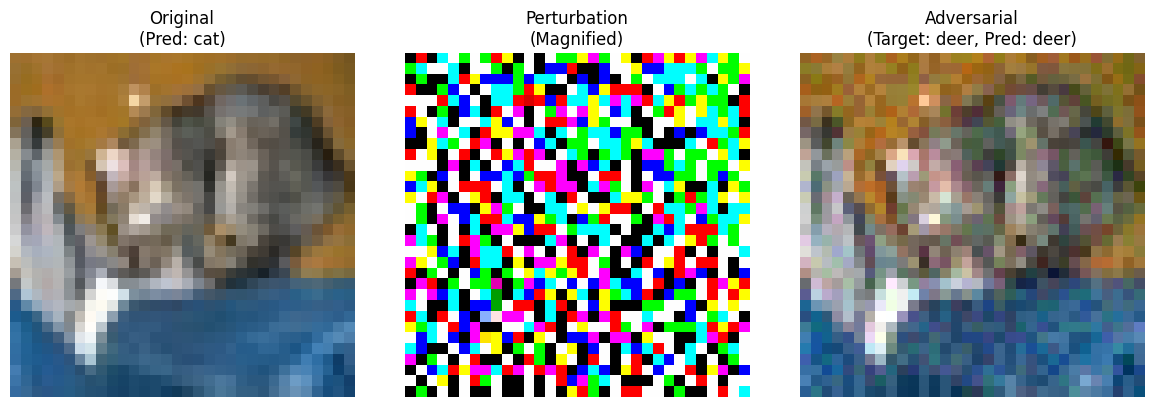

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.96862745].


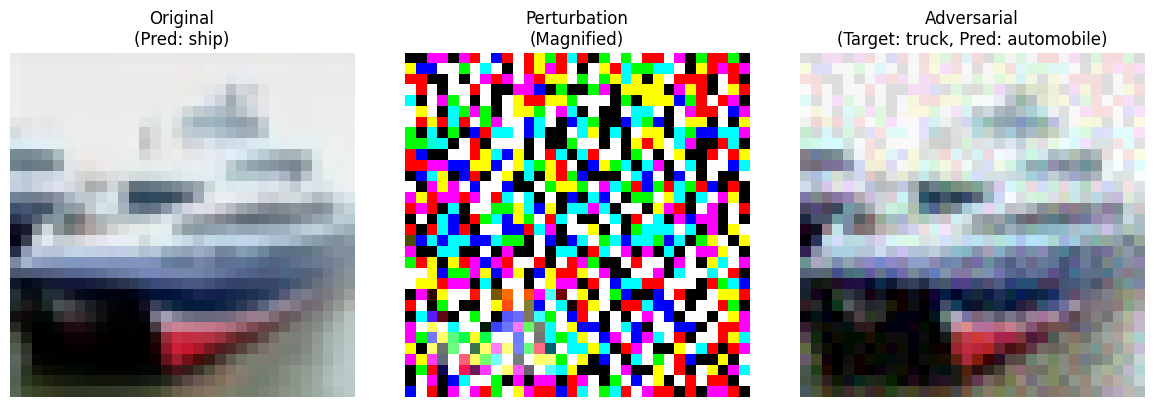

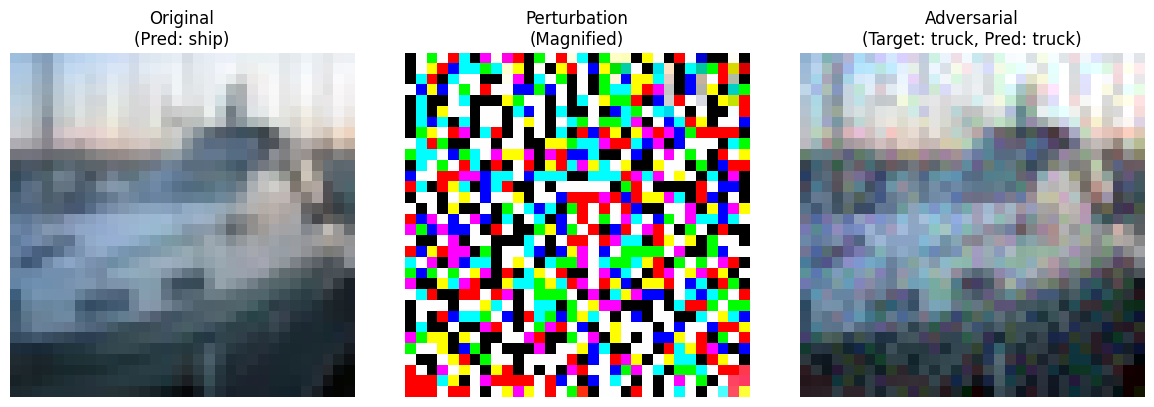

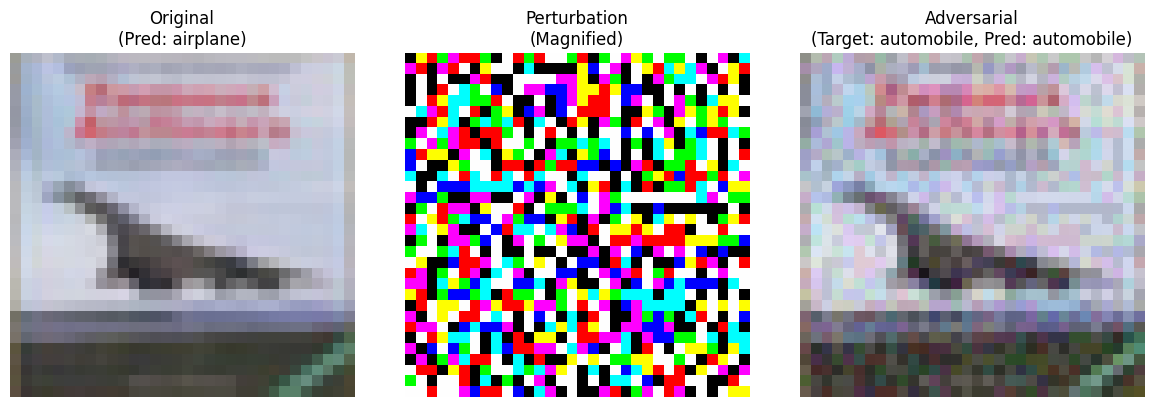

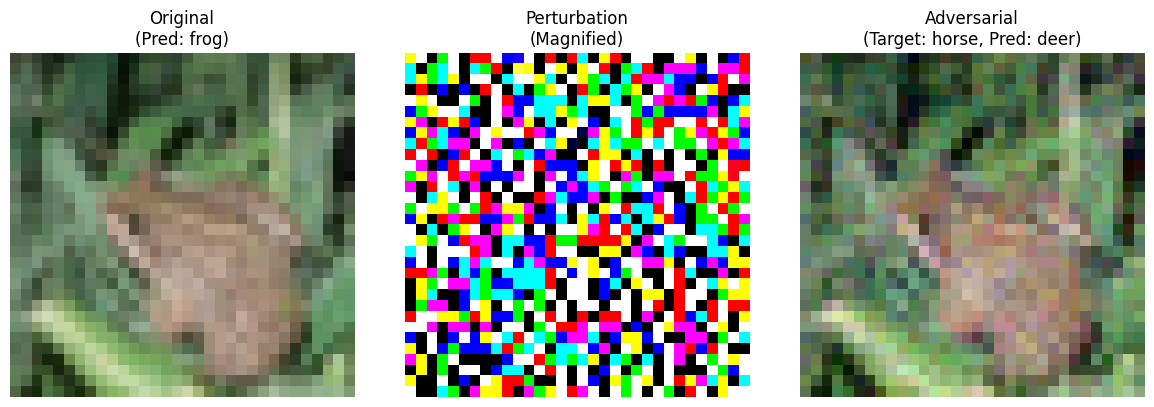

CIFAR-10 Targeted Attack Success Rate: 46.36%


In [ ]:
cifar10_model.eval()
targeted_success = 0
total_samples = 0
saved_count = 0

# CIFAR-10 테스트 로더
for data, label in cifar10_test_loader:
    data, label = data.to(device), label.to(device)
    
    # 정규화된 데이터를 [0, 1]로 복구
    data_raw = data * CIFAR_STD + CIFAR_MEAN
    
    with torch.no_grad():
        output = wrapped_cifar_model(data_raw)
        init_pred = output.max(1)[1]
    
    # 모델이 맞힌 데이터만 선택
    mask = (init_pred == label)
    if not mask.any(): continue

    x = data_raw[mask].clone().detach()
    y_true = label[mask]
    target_label = (y_true + 1) % 10 # Targeted 공격 설정 

    # 공격 수행
    x_adv = fgsm_targeted(wrapped_cifar_model, x, target_label, eps=0.05)
    
    with torch.no_grad():
        output_adv = wrapped_cifar_model(x_adv)
        final_pred = output_adv.max(1)[1]

    # 시각화 
    for i in range(len(x)):
        if saved_count < 5:
            visualize_cifar_attack(x[i:i+1], x_adv[i:i+1], target_label[i].item(), 
                                   y_true[i].item(), final_pred[i].item(), saved_count, 0.05)
            saved_count += 1

    targeted_success += (final_pred == target_label).sum().item()
    total_samples += x.size(0)
    
    if total_samples >= 100:
        break

print(f"CIFAR-10 Targeted Attack Success Rate: {100 * targeted_success / total_samples:.2f}%")

## Problem 2 Untargeted FGSM

In [ ]:
def fgsm_untargeted(model_fn, x, y_true, eps):
    # Step 0: 기울기 추적 활성화
    x.requires_grad_(True)
    
    # Step 1 & 2: 정답(y_true)과의 로짓 및 손실 계산
    logits = model_fn(x)
    loss = F.cross_entropy(logits, y_true)
    
    # Step 3: 역전파 
    mnist_model.zero_grad()
    loss.backward()
    
    # Step 4: 적대적 이미지 생성
    x_adv = x + eps * x.grad.sign()
    
    # Step 5: 범위 제한 [0, 1]
    x_adv = torch.clamp(x_adv, 0, 1)
    
    return x_adv.detach()

### 2-1 MNIST

In [ ]:
def visualize_attack(x, x_adv, clean_pred, adv_pred, index, eps):
    org_img = x.squeeze().cpu().detach().numpy()
    adv_img = x_adv.squeeze().cpu().detach().numpy()
    perturbation = adv_img - org_img
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(org_img, cmap='gray')
    plt.title(f"Original\n(Label: {clean_pred})")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(perturbation, cmap='gray', vmin=-1, vmax=1) 
    plt.title("Perturbation")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(adv_img, cmap='gray')
    plt.title(f"Adversarial\n(Pred: {adv_pred})")
    plt.axis('off')
    
    # 폴더가 없으면 생성
    os.makedirs('untargetedFGSM_results', exist_ok=True)
    plt.tight_layout()
    plt.savefig(f'untargetedFGSM_results/sample_eps{eps}_{index}.png')
    plt.show()

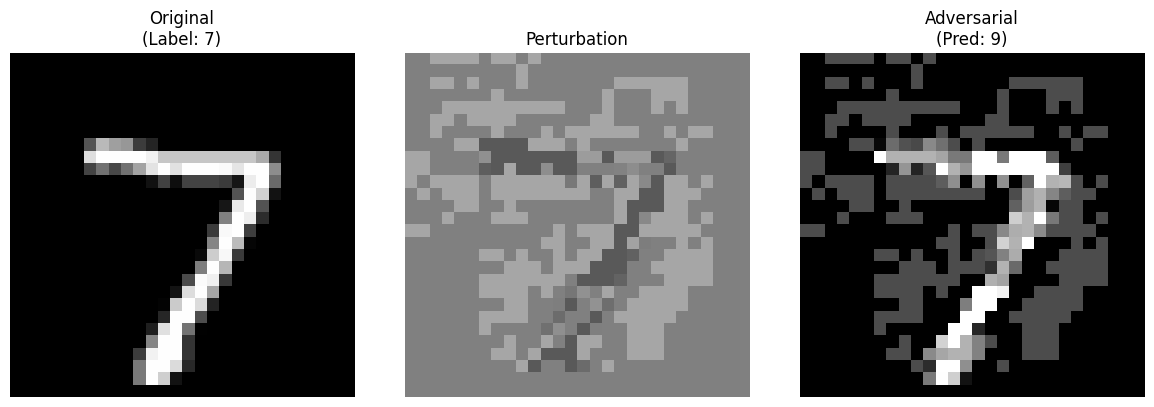

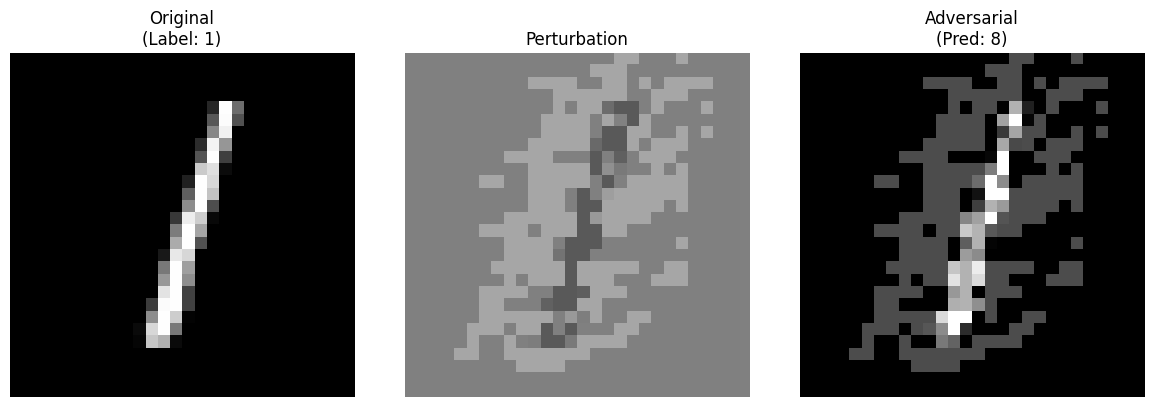

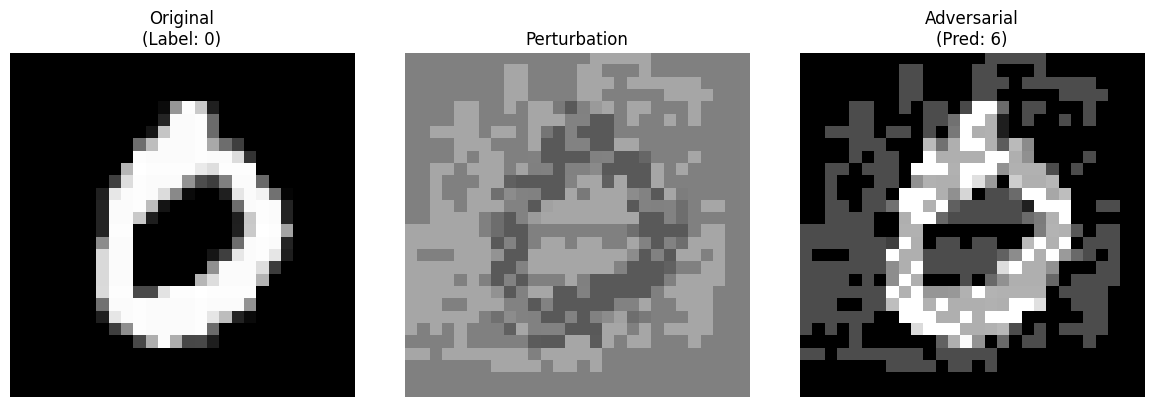

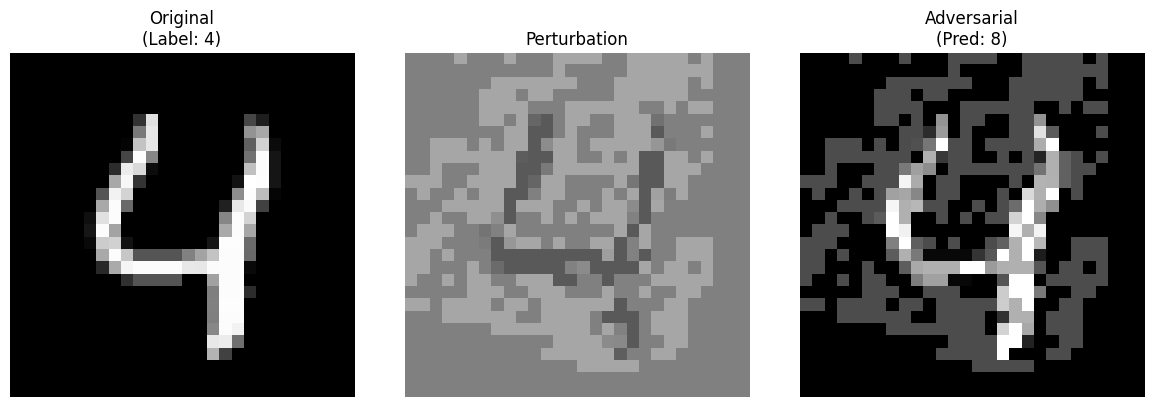

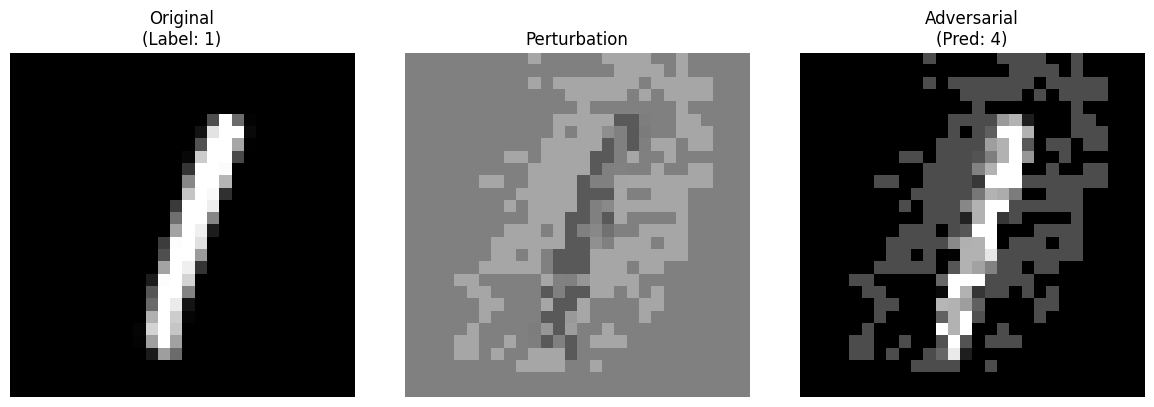

Untargeted Attack Success Rate: 78.12%


In [ ]:
mnist_model.eval()
untargeted_success = 0 
total_samples = 0
saved_count = 0

for data, label in mnist_test_loader:
    data, label = data.to(device), label.to(device)
    data_raw = data * MNIST_STD + MNIST_MEAN
    
    with torch.no_grad():
        output = mnist_wrapped_model(data_raw)
        init_pred = output.max(1)[1]
    
    mask = (init_pred == label)
    if not mask.any(): continue

    x = data_raw[mask].clone().detach()
    y_true = label[mask]
    
    # 공격 수행
    x_adv = fgsm_untargeted(mnist_wrapped_model, x, y_true, eps=0.3)
    
    with torch.no_grad():
        output_adv = mnist_wrapped_model(x_adv)
        final_pred = output_adv.max(1)[1]

    # 시각화 루프
    for i in range(len(x)):
        if saved_count < 5:
            if final_pred[i] != y_true[i]: 
                visualize_attack(
                    x[i:i+1], x_adv[i:i+1], 
                    y_true[i].item(), 
                    final_pred[i].item(), 
                    saved_count, 0.3
                )
                saved_count += 1
        else:
            break
 
    untargeted_success += (final_pred != y_true).sum().item()
    total_samples += x.size(0)
    
    if total_samples >= 100:
        break

print(f"Untargeted Attack Success Rate: {100 * untargeted_success / total_samples:.2f}%")

### 2-2 CIFAR10

In [ ]:
def visualize_cifar_attack(x, x_adv, clean_label, adv_label, index, eps):
    """
    x, x_adv: [1, 3, 32, 32] 형태의 텐서 (범위 [0, 1])
    """
    # 1. 텐서를 넘파이 배열로 변환 및 차원 변경 (C, H, W) -> (H, W, C)
    org_img = x.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    adv_img = x_adv.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    
    # 2. 노이즈(Perturbation) 계산 및 가시성 확보 
    perturbation = adv_img - org_img
    perturb_diff = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
    
    # 3. 그래프 그리기 (3개 샘플 나란히 배치) [cite: 121]
    plt.figure(figsize=(12, 4))
    
    # 원본 이미지와 예측 라벨 [cite: 122]
    plt.subplot(1, 3, 1)
    plt.imshow(org_img)
    plt.title(f"Original\n(Pred: {cifar10_classes[clean_label]})")
    plt.axis('off')
    
    # 강조된 노이즈 (차이점) 
    plt.subplot(1, 3, 2)
    plt.imshow(perturb_diff)
    plt.title("Perturbation\n(Magnified)")
    plt.axis('off')
    
    # 공격 받은 이미지와 오답 라벨 [cite: 123]
    plt.subplot(1, 3, 3)
    plt.imshow(adv_img)
    plt.title(f"Adversarial\n(Pred: {cifar10_classes[adv_label]})")
    plt.axis('off')
    
    # 4. 이미지 파일 저장 
    plt.tight_layout()
    plt.savefig(f'untargetedFGSM_results/cifar_attack_eps{eps}_{index}.png')
    plt.show()

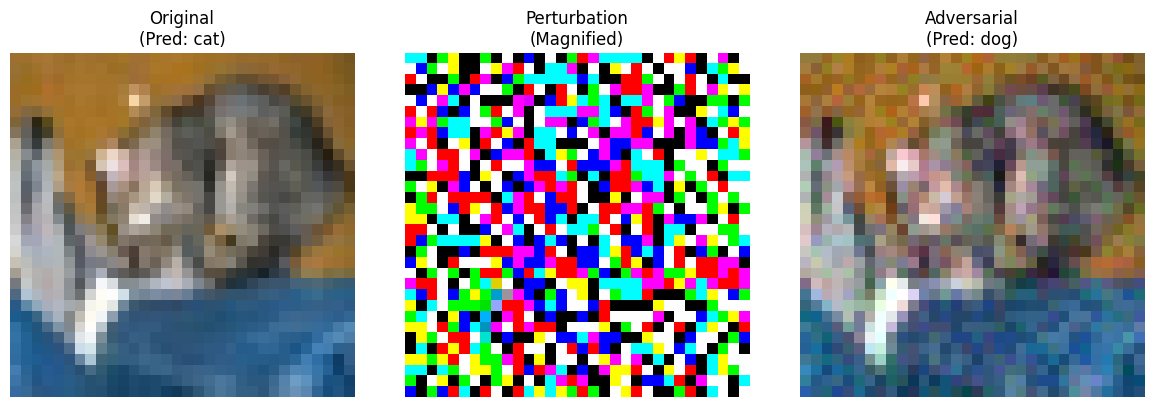

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.96862745].


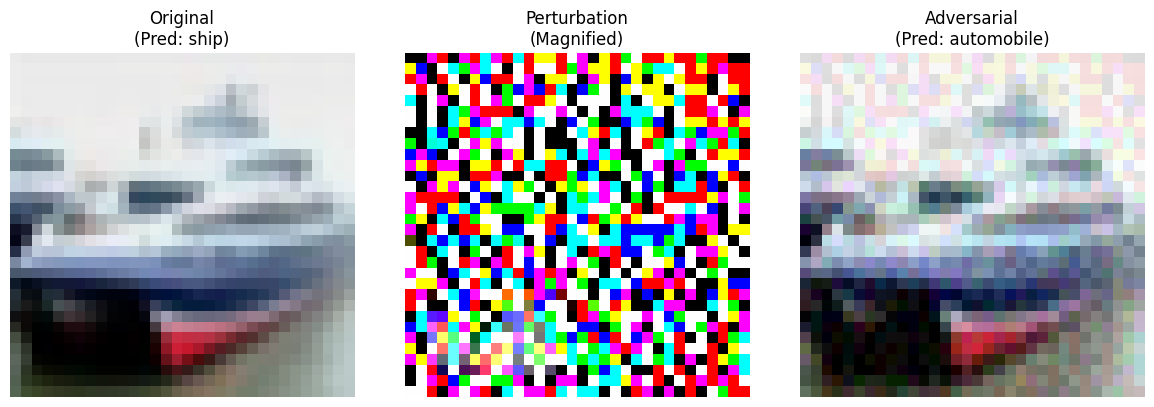

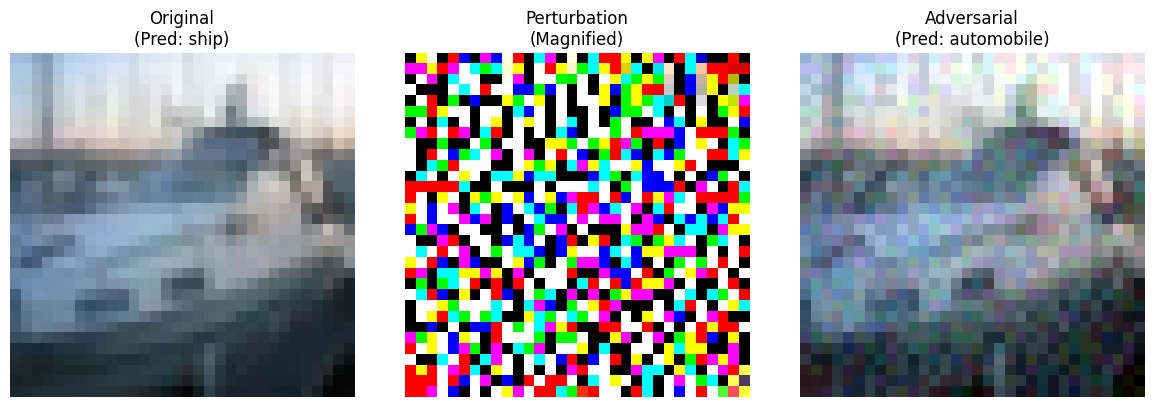

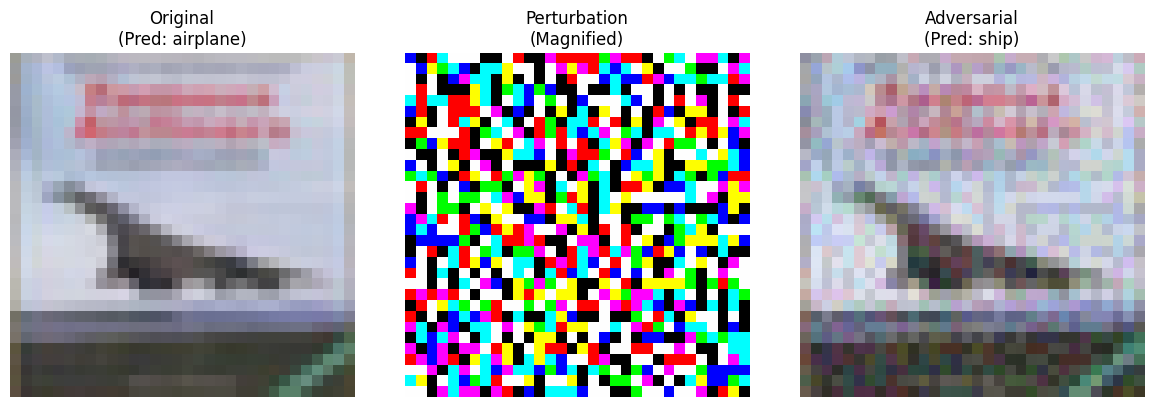

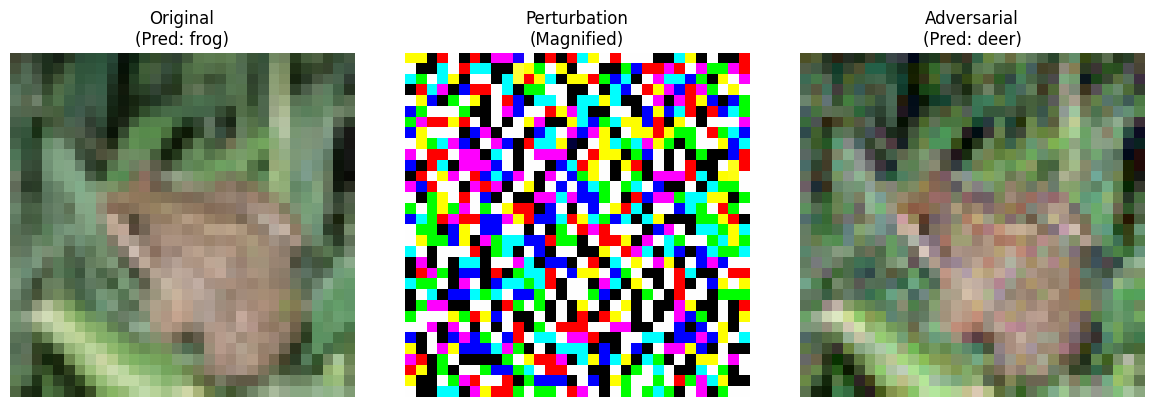

CIFAR-10 Untargeted Attack Success Rate: 98.18%


In [ ]:
cifar10_model.eval()
targeted_success = 0
total_samples = 0
saved_count = 0
untargeted_success = 0
# CIFAR-10 테스트 로더 (batch_size는 100 이상 권장)
for data, label in cifar10_test_loader:
    data, label = data.to(device), label.to(device)
    
    # 정규화된 데이터를 [0, 1]로 복구
    data_raw = data * CIFAR_STD + CIFAR_MEAN
    
    with torch.no_grad():
        output = wrapped_cifar_model(data_raw)
        init_pred = output.max(1)[1]
    
    # 모델이 맞힌 데이터만 선택 [cite: 27]
    mask = (init_pred == label)
    if not mask.any(): continue

    x = data_raw[mask].clone().detach()
    y_true = label[mask]

    # 공격 수행 (eps=0.05 ~ 0.1 권장, CIFAR는 MNIST보다 작은 eps에도 민감함)
    x_adv = fgsm_untargeted(wrapped_cifar_model, x, y_true, eps=0.05)
    
    with torch.no_grad():
        output_adv = wrapped_cifar_model(x_adv)
        final_pred = output_adv.max(1)[1]

    # 시각화 
    for i in range(len(x)):
        if saved_count < 5:
            if final_pred[i] != y_true[i]:
                visualize_cifar_attack(x[i:i+1], x_adv[i:i+1], 
                                    y_true[i].item(), final_pred[i].item(), saved_count, 0.05)
            saved_count += 1

    untargeted_success += (final_pred != y_true).sum().item()
    total_samples += x.size(0)
    
    if total_samples >= 100: 
        break

print(f"CIFAR-10 Untargeted Attack Success Rate: {100 * untargeted_success / total_samples:.2f}%")

## Problem 3-1 : Targeted Projected Gradient Descent (Targeted PGD)

In [ ]:
def pgd_targeted(model_fn, x, target, eps, alpha, iters):
    x_original = x.clone().detach()
    
    x_adv = x.clone().detach().requires_grad_(True)
    
    for i in range(iters):
        # Forward pass
        logits = model_fn(x_adv)
        loss = F.cross_entropy(logits, target)
        
        mnist_model.zero_grad() 
        cifar10_model.zero_grad()
        loss.backward()
        adv_grad = x_adv.grad.sign()
        x_adv = x_adv - alpha * adv_grad
        
   
        eta = x_adv - x_original
        
        eta = torch.clamp(eta, min=-eps, max=eps)
        x_adv = torch.clamp(x_original + eta, min=0, max=1).detach_()
        x_adv.requires_grad_(True)
        
    return x_adv.detach()

### 3-1-1 MNIST

In [ ]:

# 결과 저장 폴더 생성
os.makedirs('results_pgd_targeted', exist_ok=True)

classes = [str(i) for i in range(10)]

def visualize_pgd_targeted_result(x, x_adv, y_true_idx, y_target_idx, y_pred_idx, 
                                 eps, alpha, iters, index):
    """
    x, x_adv: [1, 1, 28, 28] 형태의 텐서, 범위 [0, 1]
    """
    org_img = x.squeeze().cpu().detach().numpy()
    adv_img = x_adv.squeeze().cpu().detach().numpy()
    
    # 노이즈(Perturbation) 계산 및 가시성 확보
    perturbation = adv_img - org_img
    
    perturb_vis = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
    

    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    
    fig.suptitle(f"PGD Targeted Attack (eps={eps}, alpha={alpha}, iters={iters})", fontsize=14)

    # 원본 이미지와 예측 라벨
    axes[0].imshow(org_img, cmap='gray')
    axes[0].set_title(f"Original\n(Label: {classes[y_true_idx]})")
    axes[0].axis('off')
    
    # 강조된 노이즈
    axes[1].imshow(perturb_vis, cmap='gray', vmin=0, vmax=1) 
    axes[1].set_title("Perturbation\n(Magnified to [0,1])")
    axes[1].axis('off')
    
    # 적대적 이미지와 타겟/최종 예측 라벨
    axes[2].imshow(adv_img, cmap='gray')
    
    title_str = f"Adversarial\nPred: {classes[y_pred_idx]}"
    axes[2].set_title(title_str)
    axes[2].axis('off')
    
    # 4. 이미지 파일 저장 및 출력
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    save_path = f'results_pgd_targeted/pgd_target_{classes[y_target_idx]}_sample_{index}.png'
    plt.savefig(save_path)
    plt.show() 

In [ ]:
N_VISUALIZATIONS = 5

clean_samples = []
adv_samples = []
true_labels = []
target_labels = []
pred_labels = []

targeted_success = 0
total_samples = 0

eps = 0.3
alpha = 0.01
iters = 40

for data, label in mnist_test_loader:
    data, label = data.to(device), label.to(device)
    data_raw = data * MNIST_STD + MNIST_MEAN # [0, 1] 범위 복구
    
    with torch.no_grad():
        output = mnist_wrapped_model(data_raw)
        init_pred = output.max(1)[1]
    
    mask = (init_pred == label)
    if not mask.any(): continue

    x = data_raw[mask].clone().detach()
    y_true = label[mask]
    
    target_idx = (y_true + 1) % 10
    
    mnist_model.zero_grad()
    x_adv = pgd_targeted(mnist_wrapped_model, x, target_idx, eps=eps, alpha=alpha, iters=iters)
    
    # 최종 결과 확인
    with torch.no_grad():
        output_adv = mnist_wrapped_model(x_adv)
        final_pred = output_adv.max(1)[1]

    for i in range(len(x)):
        if len(clean_samples) < N_VISUALIZATIONS:
            if final_pred[i] == target_idx[i]:
                clean_samples.append(x[i:i+1])
                adv_samples.append(x_adv[i:i+1])
                true_labels.append(y_true[i].item())
                target_labels.append(target_idx[i].item())
                pred_labels.append(final_pred[i].item())
        else:
            break 
            
    targeted_success += (final_pred == target_idx).sum().item()
    total_samples += x.size(0)
    
    if total_samples >= 100 and len(clean_samples) == N_VISUALIZATIONS:
        break

print(f"Targeted Success Rate: {100 * targeted_success / total_samples:.2f}%")

✅ PGD Targeted 공격 완료 (Total 992 samples)
Targeted Success Rate: 100.00%


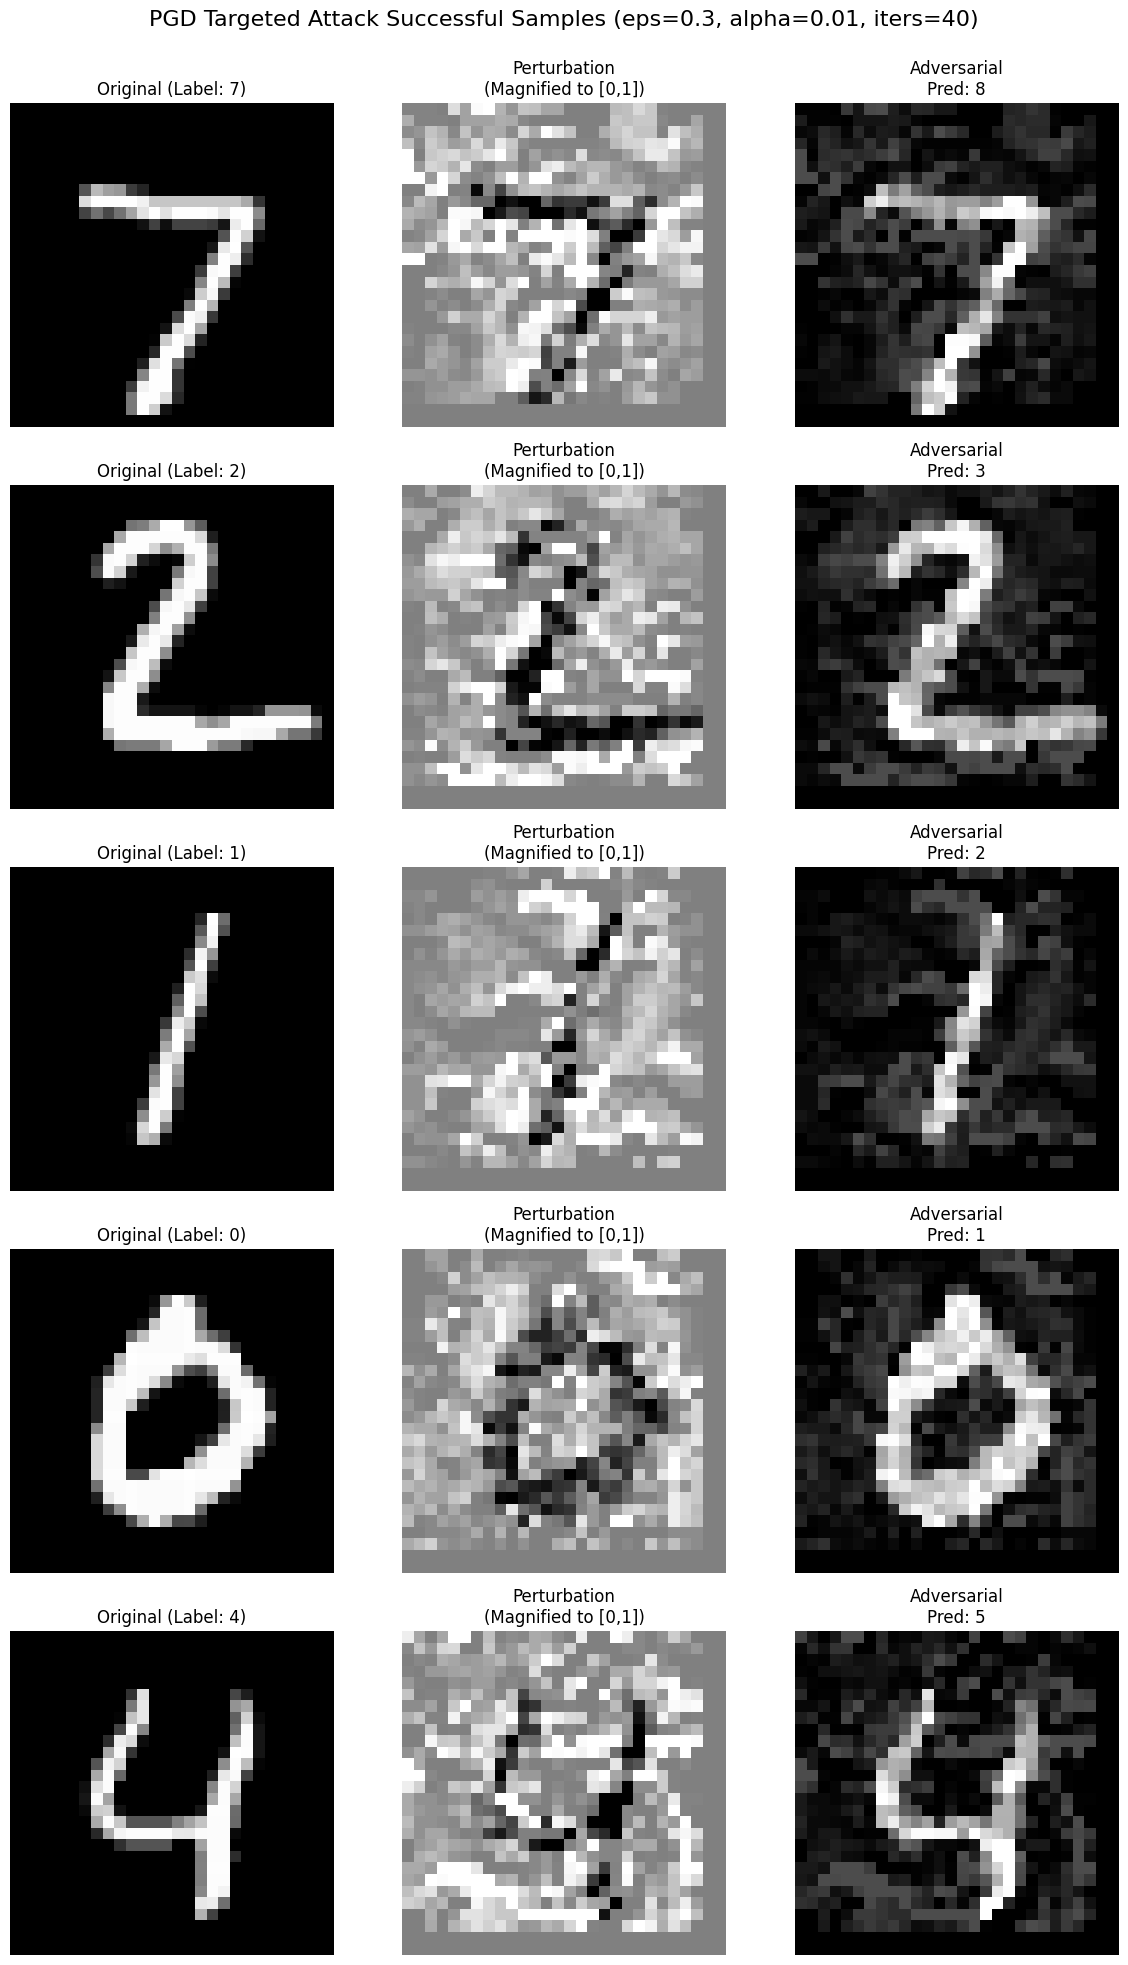

In [ ]:
os.makedirs('results_pgd_targeted_batch', exist_ok=True)

fig, axes = plt.subplots(N_VISUALIZATIONS, 3, figsize=(12, 4 * N_VISUALIZATIONS))

fig.suptitle(f"PGD Targeted Attack Successful Samples (eps={eps}, alpha={alpha}, iters={iters})", fontsize=16)

for i in range(N_VISUALIZATIONS):
    org_img = clean_samples[i].squeeze().cpu().detach().numpy()
    adv_img = adv_samples[i].squeeze().cpu().detach().numpy()
    
    perturbation = adv_img - org_img
    perturb_vis = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
    
    axes[i][0].imshow(org_img, cmap='gray')
    axes[i][0].set_title(f"Original (Label: {true_labels[i]})")
    axes[i][0].axis('off')
    
    axes[i][1].imshow(perturb_vis, cmap='gray', vmin=0, vmax=1)
    axes[i][1].set_title("Perturbation\n(Magnified to [0,1])")
    axes[i][1].axis('off')
    
    axes[i][2].imshow(adv_img, cmap='gray')
    title_str = f"Adversarial\nPred: {pred_labels[i]}"
    axes[i][2].set_title(title_str)
    axes[i][2].axis('off')
    
plt.tight_layout(rect=[0, 0, 1, 0.98]) # suptitle 영역 확보
save_path = f'results_pgd_targeted_batch/pgd_target_successful_samples.png'
plt.savefig(save_path)
plt.show() 


### 3-1-2 CIFAR-10

In [ ]:
N_VISUALIZATIONS = 5

clean_samples = []
adv_samples = []
true_labels = []
target_labels = []
pred_labels = []

targeted_success = 0
total_samples = 0

CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1).to(device)
CIFAR_STD = torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1).to(device)

eps = 0.05
alpha = 0.01
iters = 40

for data, label in cifar10_test_loader:
    data, label = data.to(device), label.to(device)
    data_raw = data * CIFAR_STD + CIFAR_MEAN # [0, 1] 범위 복구
    
    with torch.no_grad():
        output = wrapped_cifar_model(data_raw)
        init_pred = output.max(1)[1]
    
    mask = (init_pred == label)
    if not mask.any(): continue

    x = data_raw[mask].clone().detach()
    y_true = label[mask]
    target_idx = (y_true + 1) % 10
    
    cifar10_model.zero_grad() 
    x_adv = pgd_targeted(wrapped_cifar_model, x, target_idx, eps=eps, alpha=alpha, iters=iters)
    
    with torch.no_grad():
        output_adv = wrapped_cifar_model(x_adv)
        final_pred = output_adv.max(1)[1]

    for i in range(len(x)):
        if len(clean_samples) < N_VISUALIZATIONS:
            if final_pred[i] == target_idx[i]:
                clean_samples.append(x[i:i+1])
                adv_samples.append(x_adv[i:i+1])
                true_labels.append(y_true[i].item())
                target_labels.append(target_idx[i].item())
                pred_labels.append(final_pred[i].item())
        else:
            break
            
    # 성공률 계산
    targeted_success += (final_pred == target_idx).sum().item()
    total_samples += x.size(0)
    
    # 중단 조건
    if total_samples >= 100 and len(clean_samples) == N_VISUALIZATIONS:
        break

print(f"CIFAR-10 Targeted Success Rate: {100 * targeted_success / total_samples:.2f}%")


✅ PGD Targeted 공격 완료 (Total 110 samples)
Targeted Success Rate: 100.00%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.96862745].


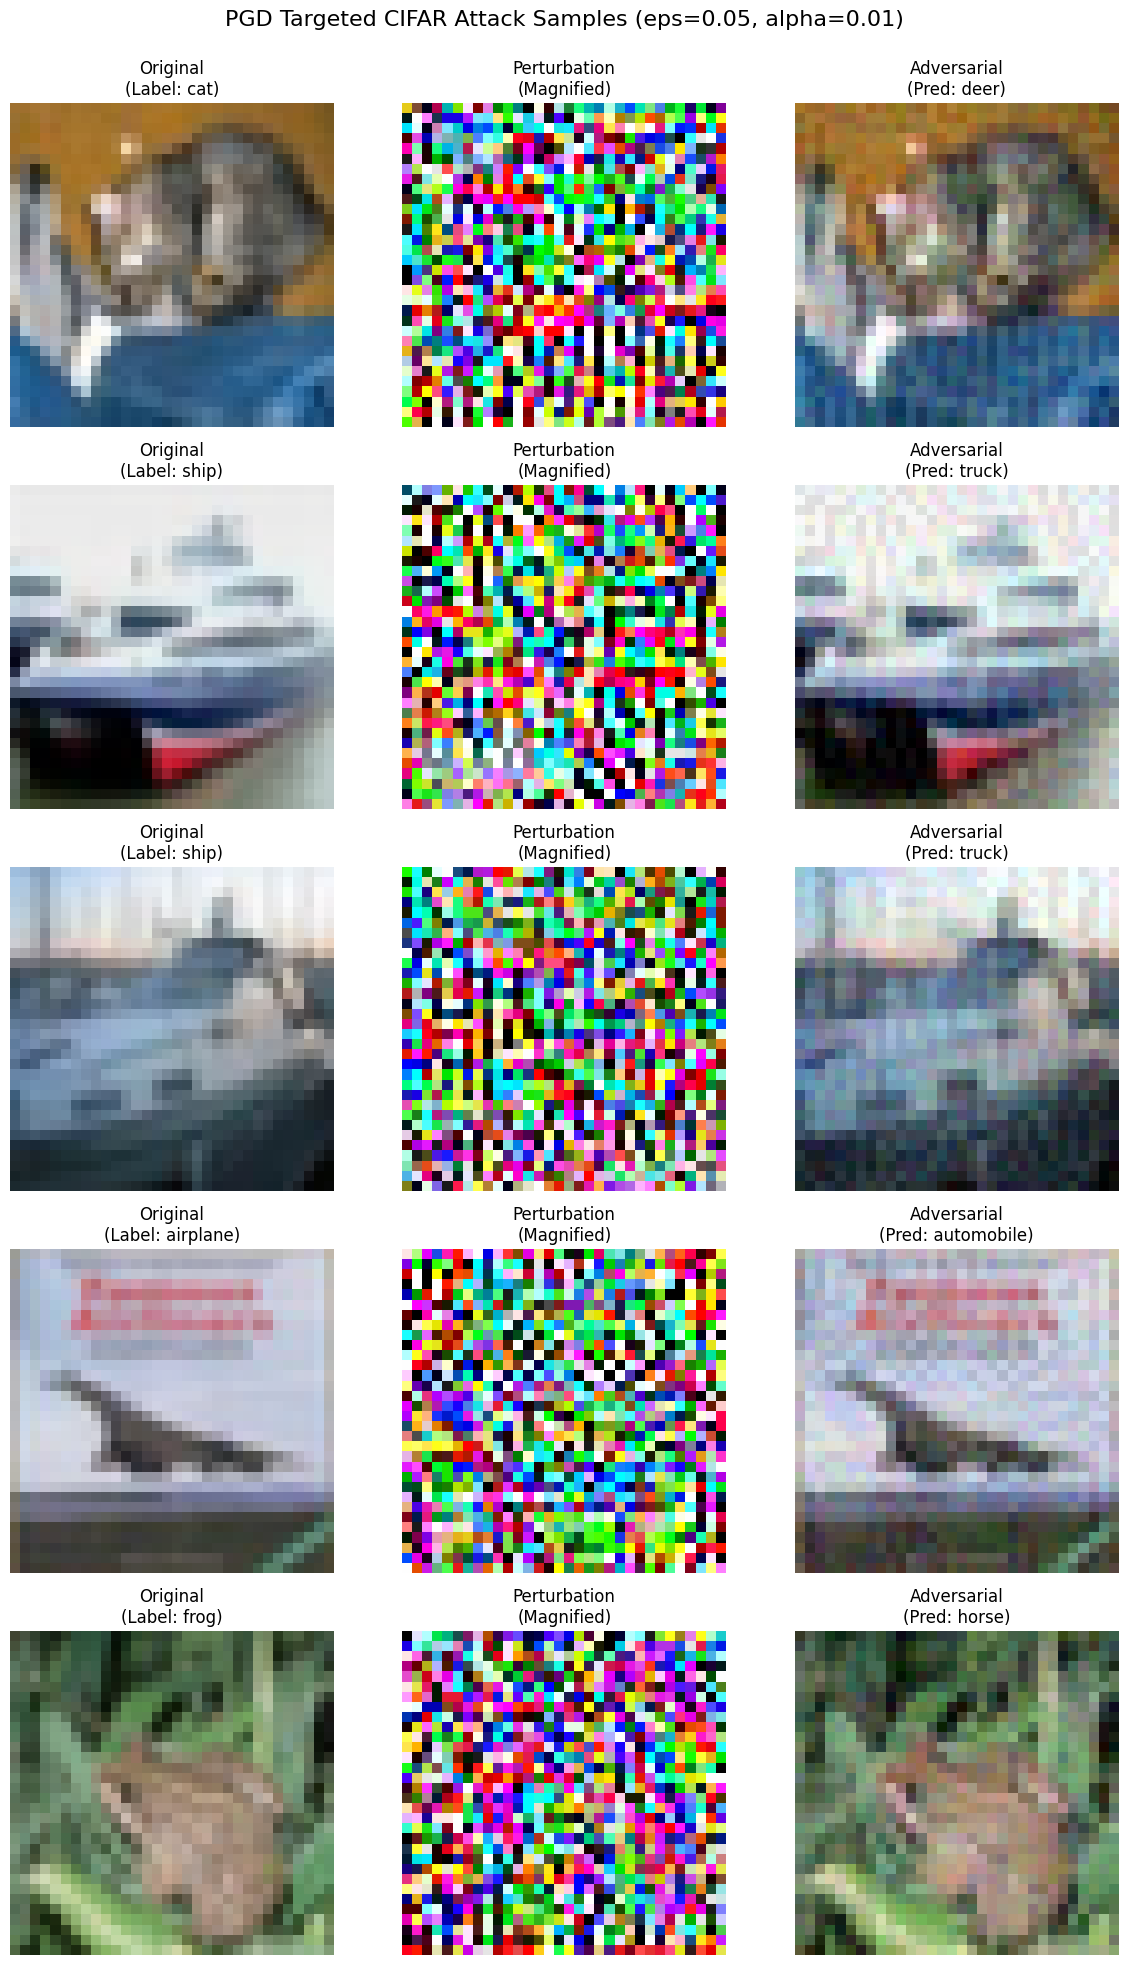

In [ ]:
num_to_show = len(clean_samples)
fig, axes = plt.subplots(num_to_show, 3, figsize=(12, 4 * num_to_show))

fig.suptitle(f"PGD Targeted CIFAR Attack Samples (eps={eps}, alpha={alpha})", fontsize=16)

if num_to_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_to_show):
    org_img = clean_samples[i].squeeze().permute(1, 2, 0).cpu().detach().numpy()
    adv_img = adv_samples[i].squeeze().permute(1, 2, 0).cpu().detach().numpy()
    
    # 노이즈 계산 및 확대
    perturbation = adv_img - org_img
    # 노이즈는 차이를 극대화해서 보여주기 위해 정규화
    perturb_vis = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
    
    axes[i][0].imshow(org_img)
    axes[i][0].set_title(f"Original\n(Label: {cifar10_classes[true_labels[i]]})")
    axes[i][0].axis('off')
    
    axes[i][1].imshow(perturb_vis)
    axes[i][1].set_title("Perturbation\n(Magnified)")
    axes[i][1].axis('off')
    
    axes[i][2].imshow(adv_img)
    axes[i][2].set_title(f"Adversarial\n(Pred: {cifar10_classes[pred_labels[i]]})")
    axes[i][2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
save_path = f'results_pgd_targeted_batch/cifar10_pgd_target_successful_samples.png'
plt.savefig(save_path)
plt.show()

## Problem 3-2 : Untargeted Projected Gradient Descent (UnTargeted PGD)

In [ ]:
def pgd_untargeted(model_fn, x, y_true, eps, alpha, iters):
    x_original = x.clone().detach()
    
    x_adv = x.clone().detach().requires_grad_(True)
    
    for i in range(iters):
        # Forward pass
        logits = model_fn(x_adv)
        
        # [차이점] 실제 정답(y_true)과의 손실 계산
        loss = F.cross_entropy(logits, y_true)
        
        mnist_model.zero_grad() 
        cifar10_model.zero_grad() # 실제 모델 객체 초기화
        loss.backward()
        
        adv_grad = x_adv.grad.sign()
        x_adv = x_adv + alpha * adv_grad
        
        # --- Projection 단계 (L-inf ball) ---
        eta = x_adv - x_original
        eta = torch.clamp(eta, min=-eps, max=eps)
        
        # 이미지 범위 [0, 1] 제한 및 다시 텐서 준비
        x_adv = torch.clamp(x_original + eta, min=0, max=1).detach_()
        x_adv.requires_grad_(True)
        
    return x_adv.detach()

### 3-2-1 MNIST

In [ ]:

# 결과 저장 폴더 생성
os.makedirs('results_pgd_targeted', exist_ok=True)

# MNIST 클래스 이름 (0~9)
classes = [str(i) for i in range(10)]

def visualize_pgd_untargeted_mnist_result(x, x_adv, y_true_idx, y_pred_idx,
                                 eps, alpha, iters, index):
    """
    x, x_adv: [1, 1, 28, 28] 형태의 텐서, 범위 [0, 1]
    """
    # 텐서를 CPU로 옮기고 넘파이 배열로 변환
    org_img = x.squeeze().cpu().detach().numpy()
    adv_img = x_adv.squeeze().cpu().detach().numpy()
    
    # 2. 노이즈(Perturbation) 계산 및 가시성 확보
    perturbation = adv_img - org_img
    
    perturb_vis = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
    
    # 3. 그래프 그리기 (3개 샘플 나란히 배치)
    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    
    fig.suptitle(f"PGD Targeted Attack (eps={eps}, alpha={alpha}, iters={iters})", fontsize=14)

    axes[0].imshow(org_img, cmap='gray')
    axes[0].set_title(f"Original\n(Label: {classes[y_true_idx]})")
    axes[0].axis('off')
    
    axes[1].imshow(perturb_vis, cmap='gray', vmin=0, vmax=1) 
    axes[1].set_title("Perturbation\n(Magnified to [0,1])")
    axes[1].axis('off')
    
    axes[2].imshow(adv_img, cmap='gray')
    
    title_str = f"Adversarial\nPred: {classes[y_pred_idx]}"
    axes[2].set_title(title_str)
    axes[2].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # suptitle 영역 확보
    save_path = f'results_pgd_untargeted/pgd_untargeted_sample_{index}.png'
    plt.savefig(save_path)
    plt.show() # 노트북에 출력

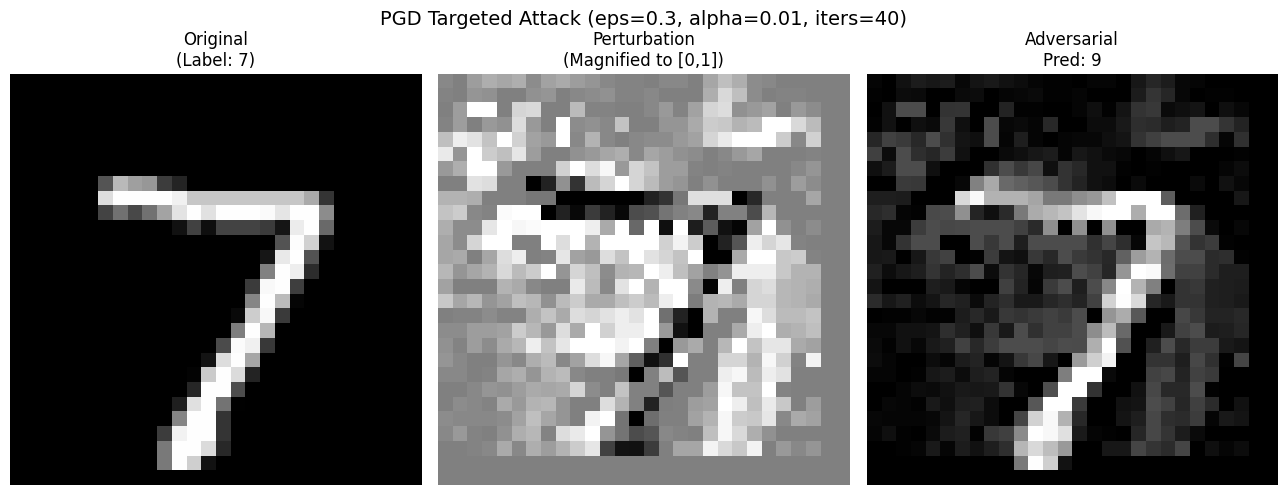

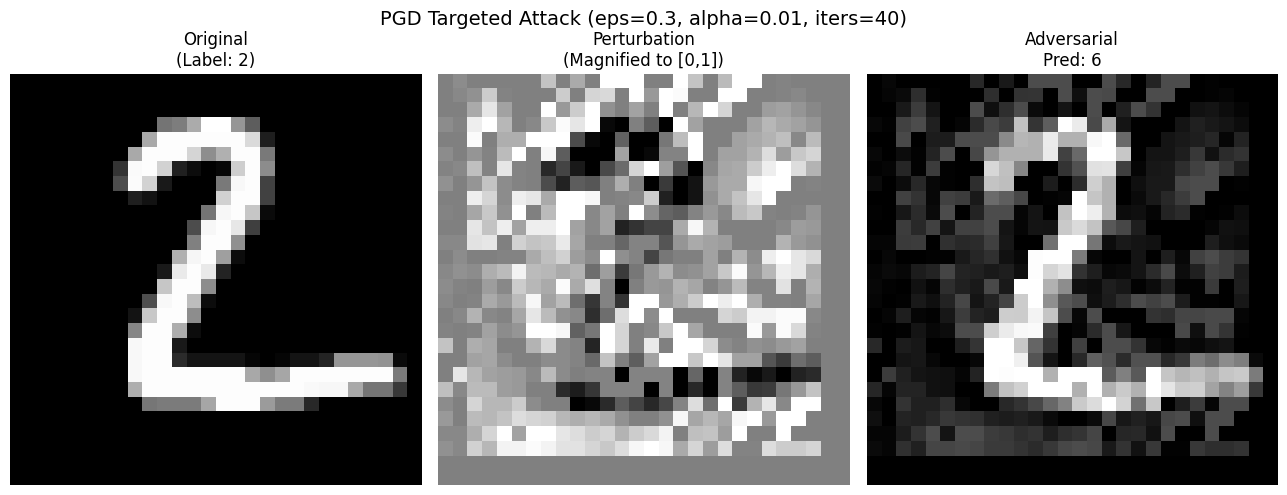

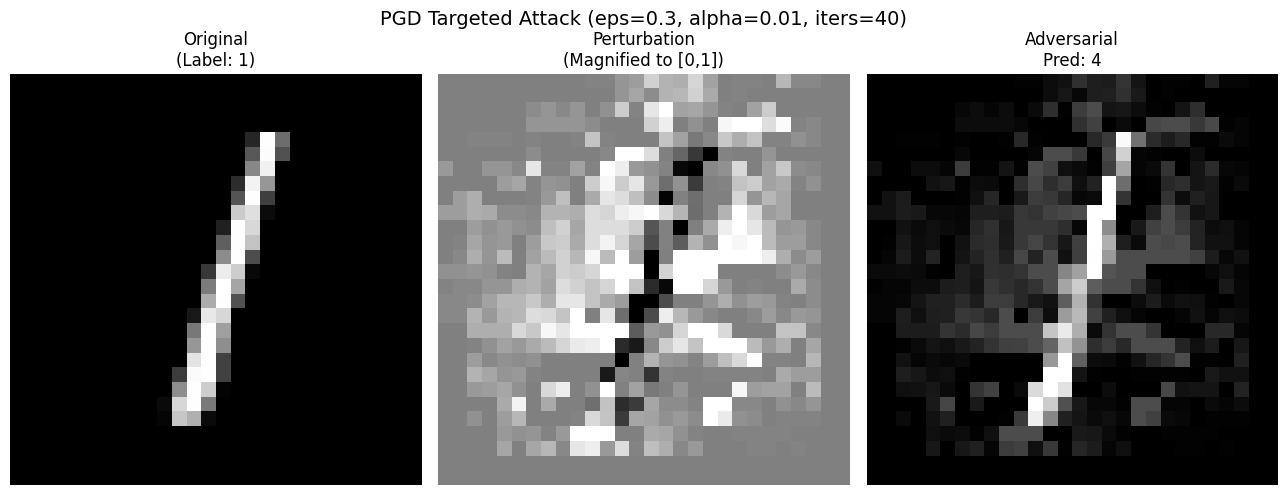

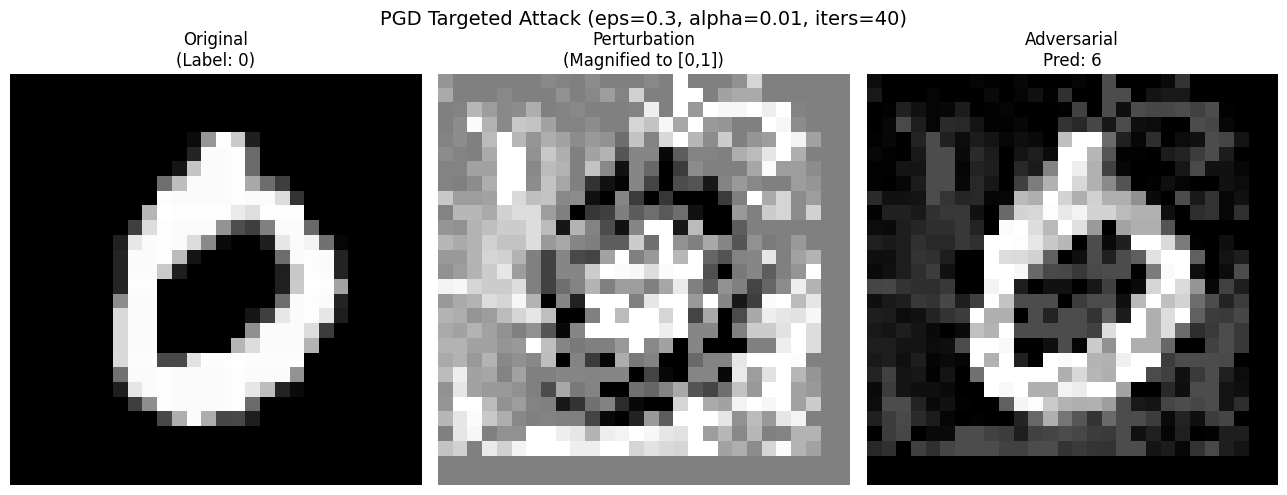

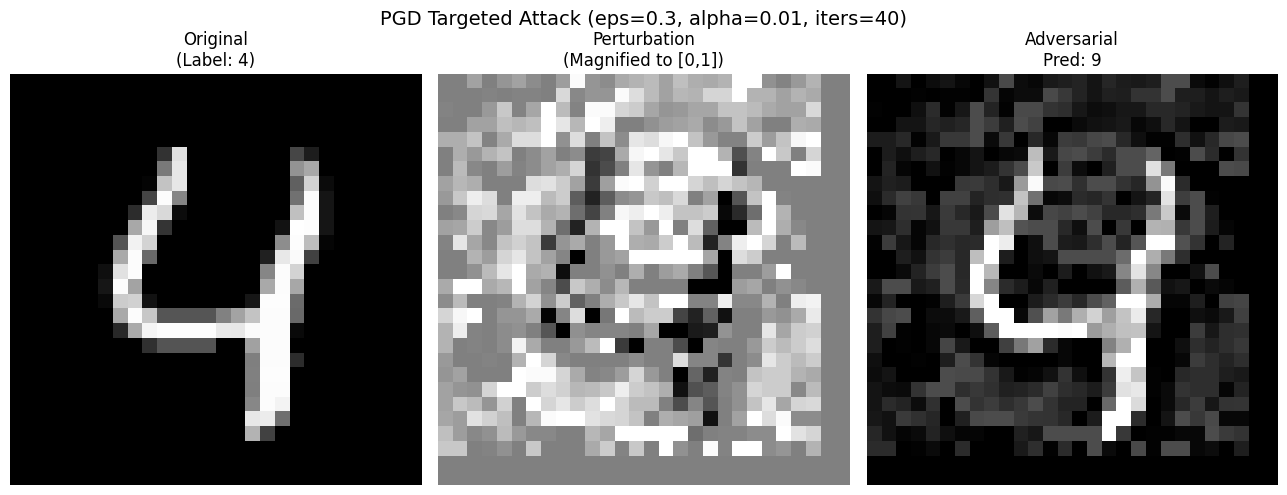

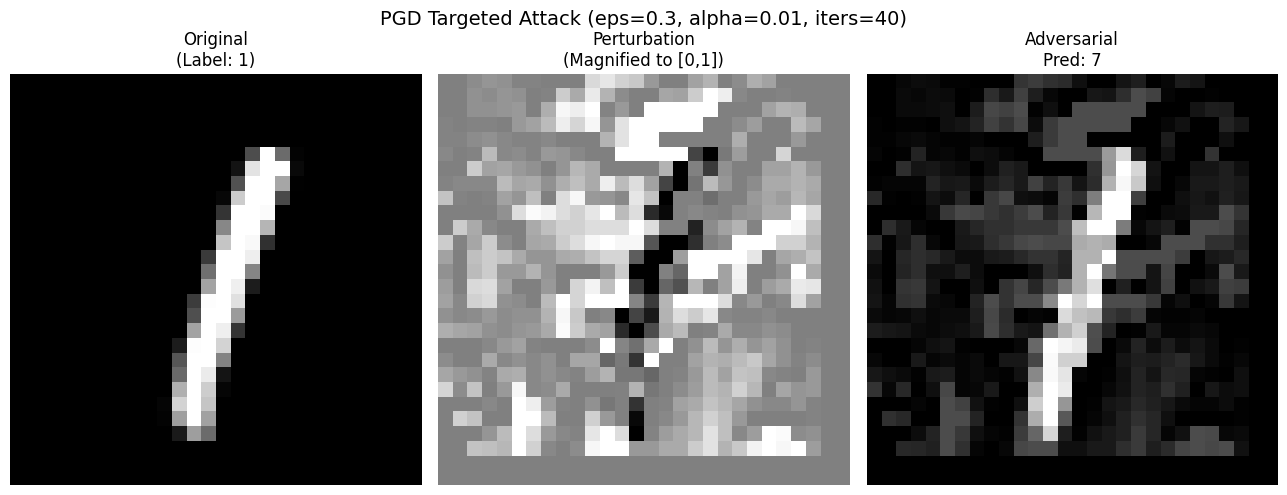

✅ PGD Targeted 공격 완료 (Total 9925 samples)
Targeted Success Rate: 99.96%


In [ ]:
N_VISUALIZATIONS = 5

clean_samples = []
adv_samples = []
true_labels = []
pred_labels = []
saved_count = 0
targeted_success = 0
total_samples = 0

eps = 0.3
alpha = 0.01
iters = 40

for data, label in mnist_test_loader:
    data, label = data.to(device), label.to(device)
    data_raw = data * MNIST_STD + MNIST_MEAN # [0, 1] 범위 복구
    
    with torch.no_grad():
        output = mnist_wrapped_model(data_raw)
        init_pred = output.max(1)[1]
    
    mask = (init_pred == label)
    if not mask.any(): continue

    x = data_raw[mask].clone().detach()
    y_true = label[mask]
    
    mnist_model.zero_grad() 
    x_adv = pgd_untargeted(mnist_wrapped_model, x, y_true, eps=eps, alpha=alpha, iters=iters)
    
    
    with torch.no_grad():
        output_adv = mnist_wrapped_model(x_adv)
        final_pred = output_adv.max(1)[1]

    for i in range(len(x)):
    
        if len(clean_samples) < N_VISUALIZATIONS and saved_count < 6:
            if final_pred[i] != y_true[i]: 
                visualize_pgd_untargeted_mnist_result(
                    x[i:i+1],          
                    x_adv[i:i+1], 
                    y_true[i].item(),  
                    final_pred[i].item(), 
                    eps, alpha, iters, 
                    saved_count        
                )
                saved_count += 1
        else:
            break 
            
    # 성공률 계산
    targeted_success += (final_pred != y_true).sum().item()
    total_samples += x.size(0)
    
    
    if total_samples >= 100 and len(clean_samples) == N_VISUALIZATIONS:
        break

# 성공률 출력
print(f"Targeted Success Rate: {100 * targeted_success / total_samples:.2f}%")

### 3-2-2 CIFAR-10 PGD Untargeted Attack

In [ ]:

os.makedirs('results_pgd_targeted', exist_ok=True)

# MNIST 클래스 이름 (0~9)
classes = [str(i) for i in range(10)]

def visualize_pgd_untargeted_cifar10_result(x, x_adv, y_true_idx, y_pred_idx,
                                 eps, alpha, iters, index):
    org_img = x.squeeze().cpu().detach().numpy()
    adv_img = x_adv.squeeze().cpu().detach().numpy()
    
    perturbation = adv_img - org_img
    
    perturb_vis = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
    
    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    
    fig.suptitle(f"PGD Targeted Attack (eps={eps}, alpha={alpha}, iters={iters})", fontsize=14)

    axes[0].imshow(org_img, cmap=)
    axes[0].set_title(f"Original\n(Label: {classes[y_true_idx]})")
    axes[0].axis('off')
    
    axes[1].imshow(perturb_vis, cmap='gray', vmin=0, vmax=1) 
    axes[1].set_title("Perturbation\n(Magnified to [0,1])")
    axes[1].axis('off')
    
    axes[2].imshow(adv_img, cmap='gray')
    
    title_str = f"Adversarial\nPred: {classes[y_pred_idx]}"
    axes[2].set_title(title_str)
    axes[2].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_path = f'results_pgd_untargeted/pgd_untargeted_sample_{index}.png'
    plt.savefig(save_path)
    plt.show() 

In [ ]:
N_VISUALIZATIONS = 5

clean_samples = []
adv_samples = []
true_labels = []
pred_labels = []

targeted_success = 0
total_samples = 0

CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1).to(device)
CIFAR_STD = torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1).to(device)

eps = 0.05
alpha = 0.01
iters = 40

for data, label in cifar10_test_loader:
    data, label = data.to(device), label.to(device)
    data_raw = data * CIFAR_STD + CIFAR_MEAN 
    
    with torch.no_grad():
        output = wrapped_cifar_model(data_raw)
        init_pred = output.max(1)[1]

    mask = (init_pred == label)
    if not mask.any(): continue

    x = data_raw[mask].clone().detach()
    y_true = label[mask]

    cifar10_model.zero_grad() # 기울기 초기화 중요!
    x_adv = pgd_untargeted(wrapped_cifar_model, x,y_true, eps=eps, alpha=alpha, iters=iters)
    
    # 최종 결과 확인
    with torch.no_grad():
        output_adv = wrapped_cifar_model(x_adv)
        final_pred = output_adv.max(1)[1]


    for i in range(len(x)):
        if len(clean_samples) < N_VISUALIZATIONS:
            if final_pred[i] != y_true[i]: # 공격 성공!
                clean_samples.append(x[i:i+1])
                adv_samples.append(x_adv[i:i+1])
                true_labels.append(y_true[i].item())
                pred_labels.append(final_pred[i].item())
        else:
            break 
            
    targeted_success += (final_pred != y_true).sum().item()
    total_samples += x.size(0)
    
    if total_samples >= 100 and len(clean_samples) == N_VISUALIZATIONS:
        break

# 성공률 출력
print(f"Targeted Success Rate: {100 * targeted_success / total_samples:.2f}%")

✅ PGD Targeted 공격 완료 (Total 110 samples)
Targeted Success Rate: 100.00%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.96862745].


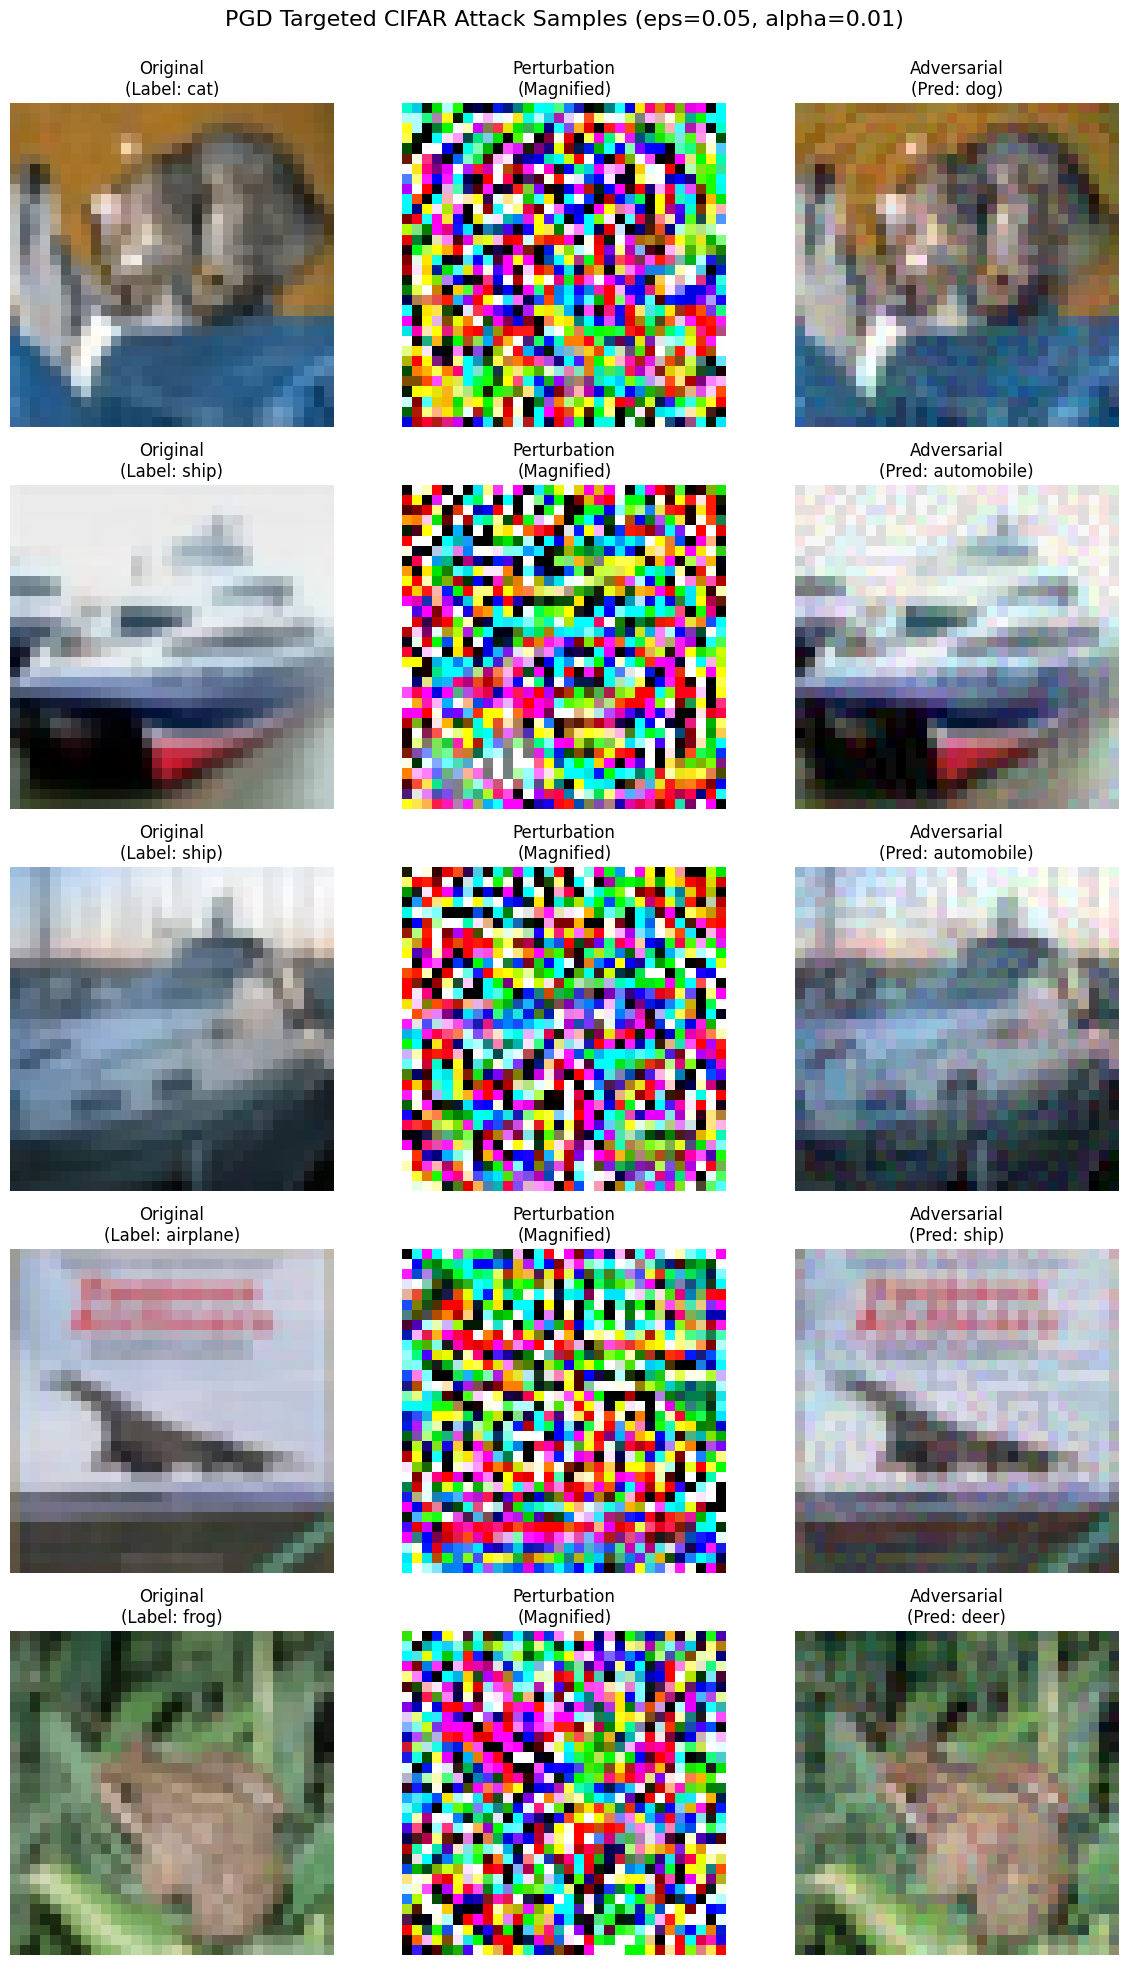

In [ ]:
num_to_show = len(clean_samples)
fig, axes = plt.subplots(num_to_show, 3, figsize=(12, 4 * num_to_show))

fig.suptitle(f"PGD Targeted CIFAR Attack Samples (eps={eps}, alpha={alpha})", fontsize=16)

if num_to_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_to_show):
    org_img = clean_samples[i].squeeze().permute(1, 2, 0).cpu().detach().numpy()
    adv_img = adv_samples[i].squeeze().permute(1, 2, 0).cpu().detach().numpy()
    
    perturbation = adv_img - org_img
    perturb_vis = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
    
    axes[i][0].imshow(org_img)
    axes[i][0].set_title(f"Original\n(Label: {cifar10_classes[true_labels[i]]})")
    axes[i][0].axis('off')
    
    axes[i][1].imshow(perturb_vis)
    axes[i][1].set_title("Perturbation\n(Magnified)")
    axes[i][1].axis('off')
    
    axes[i][2].imshow(adv_img)
    axes[i][2].set_title(f"Adversarial\n(Pred: {cifar10_classes[pred_labels[i]]})")
    axes[i][2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
save_path = f'results_pgd_untargeted_batch/cifar10_pgd_untarget_successful_samples.png'
plt.savefig(save_path)
plt.show()